# 03 Desbalanceo y coste

En el notebook anterior se seleccionó el modelo principal siguiendo el protocolo de evaluación con **GridSearchCV**, **5-fold CV** y uso exclusivo de train para la selección. Este notebook no sustituye esa selección. Su objetivo es profundizar en una cuestión práctica del problema APS.

La clase positiva es muy minoritaria y, además, los errores no tienen el mismo impacto. Un falso positivo implica revisar un camión que no tenía fallo APS. Un falso negativo implica no detectar un fallo APS real. En un contexto de mantenimiento, este segundo error puede ser mucho más grave.

Por eso, en este notebook no solo se mira si una estrategia predice mejor, sino también qué tipo de errores comete y cuánto cuestan. La función de coste usada asigna **10** a cada falso positivo y **500** a cada falso negativo. Esta elección refleja que revisar de más tiene coste, pero dejar escapar un fallo puede tener consecuencias mayores.

La comparación se mantiene dentro del protocolo experimental. Las estrategias se seleccionan con validación cruzada sobre train.

## Preparación

Esta celda carga las librerías, los datos procesados y las métricas necesarias para analizar desbalanceo y coste. También define la validación cruzada de 5 folds.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from project_utils import *

RANDOM_STATE = 42
crear_carpetas(".")
sns.set_theme(style="whitegrid")


El entorno queda preparado para comparar estrategias de forma reproducible.


## Datos y validación

Esta sección carga train y test y separa variables predictoras y objetivo.

Las métricas de CV se centran en la clase positiva. PR-AUC resume la calidad del ranking en un problema desbalanceado. Recall positivo mide cuántos fallos APS se detectan. F1 mide el equilibrio entre detectar fallos y no generar demasiadas falsas alarmas.

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

train_df = cargar_csv("data/processed/train.csv")
test_df = cargar_csv("data/processed/test.csv")
X_train, y_train = separar_x_y(train_df)
X_test, y_test = separar_x_y(test_df)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"average_precision": "average_precision", "recall_pos": make_scorer(recall_score, pos_label=1, zero_division=0), "f1_pos": make_scorer(f1_score, pos_label=1, zero_division=0)}

## Estrategias comparadas

Esta sección compara varias estrategias para estudiar el efecto del desbalanceo sin cambiar el protocolo experimental del notebook anterior. El objetivo no es sustituir el modelo principal, sino comprobar cómo cambian las métricas y el coste cuando se da más importancia a la clase positiva.

Se incluyen dos versiones de regresión logística. La primera, **logistic_sin_ajuste**, entrena el modelo sin ponderar las clases. La segunda, **logistic_class_weight**, usa **class_weight balanced** para penalizar más los errores sobre la clase minoritaria durante el entrenamiento.

También se incluye **rf_class_weight**, que aplica pesos de clase en Random Forest. Esta estrategia permite comprobar si un ensemble de árboles con ponderación de clases mejora la detección de fallos APS. Además, se mantiene **hgb_sin_ajuste**, que sirve como referencia del modelo principal seleccionado en el notebook anterior.

Todas las estrategias incluyen imputación con mediana dentro del **Pipeline**. En las regresiones logísticas también se añade escalado, porque son modelos sensibles a la escala de las variables. Los modelos de árboles no necesitan escalado de la misma forma.

Cada estrategia se evalúa con **GridSearchCV** y **5-fold CV** usando solo train. La métrica de selección vuelve a ser **average precision**, ya que el problema está muy desbalanceado y la clase positiva es la más importante. Test no participa en esta comparación y queda reservado para la evaluación final.

In [ ]:
estrategias = {
    "logistic_sin_ajuste": (Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]), {"model__C": [0.1, 1, 10]}),
    "logistic_class_weight": (Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))]), {"model__C": [0.1, 1, 10]}),
    "rf_class_weight": (Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1))]), {"model__max_depth": [None, 15], "model__min_samples_leaf": [1, 5]}),
    "hgb_sin_ajuste": (Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))]), {"model__max_iter": [100, 200], "model__learning_rate": [0.05, 0.1]}),
}

cv_rows = []
models = {}
for nombre, (pipe, params) in estrategias.items():
    print("Entrenando", nombre)
    grid = GridSearchCV(pipe, params, cv=cv, scoring=scoring, refit="average_precision", n_jobs=1)
    grid.fit(X_train, y_train)
    models[nombre] = grid.best_estimator_
    cv_rows.append({
        "modelo": nombre,
        "cv_average_precision": grid.best_score_,
        "cv_recall_pos": grid.cv_results_["mean_test_recall_pos"][grid.best_index_],
        "cv_f1_pos": grid.cv_results_["mean_test_f1_pos"][grid.best_index_],
        "best_params": str(grid.best_params_),
    })

strategy_cv_results = pd.DataFrame(cv_rows).sort_values("cv_average_precision", ascending=False)
strategy_cv_results.to_csv("artifacts/metrics/imbalance_strategy_cv.csv", index=False)
selected_strategy_cv = strategy_cv_results.iloc[0]["modelo"]
guardar_json({
    "selected_strategy": selected_strategy_cv,
    "selection_metric": "cv_average_precision",
    "note": "Seleccion hecha solo con CV en train. Test no participa."
}, "artifacts/metrics/selected_imbalance_strategy_by_cv.json")
strategy_cv_results

Entrenando logistic_sin_ajuste
Entrenando logistic_class_weight
Entrenando rf_class_weight
Entrenando hgb_sin_ajuste


  File "c:\Users\mauro\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\mauro\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\mauro\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\mauro\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


,modelo,cv_average_precision,cv_recall_pos,cv_f1_pos,best_params
3,hgb_sin_ajuste,0.881018,0.738,0.808990,"{'model__learning_rate': 0.05, 'model__max_ite..."
2,rf_class_weight,0.834284,0.570,0.701410,"{'model__max_depth': None, 'model__min_samples..."
0,logistic_sin_ajuste,0.771443,0.631,0.706005,{'model__C': 0.1}
1,logistic_class_weight,0.739963,0.903,0.547283,{'model__C': 0.1}


La tabla de CV muestra el primer trade-off importante del notebook. **hgb_sin_ajuste** obtiene la mejor **PR-AUC media**, cercana a **0.881**, y también mantiene un **F1 positivo** alto, cercano a **0.809**. Según la métrica principal definida antes de mirar test, esta es la estrategia seleccionada.

La columna **best_params** recoge la mejor configuración encontrada por **GridSearchCV** dentro de train. Esto confirma que se está haciendo una búsqueda sistemática de hiperparámetros. En las regresiones logísticas, por ejemplo, la mejor configuración usa **C igual a 0.1**, lo que indica una regularización más fuerte que en valores mayores de C.

**rf_class_weight** queda en segunda posición por PR-AUC, con un valor cercano a **0.834**, pero su **recall positivo** es más bajo, cercano a **0.570**. Esto indica que ponderar la clase positiva en Random Forest no mejora aquí la detección de fallos APS frente a HGB.

**logistic_sin_ajuste** obtiene una PR-AUC cercana a **0.771** y un F1 positivo cercano a **0.706**. Es peor que los ensembles, pero funciona mucho mejor que un baseline trivial. Esto la convierte en una referencia simple e interpretable.

**logistic_class_weight** muestra un comportamiento distinto. Su **recall positivo** en CV es muy alto, cercano a **0.903**, lo que indica que detecta más fallos APS. Sin embargo, su **F1 positivo** baja hasta aproximadamente **0.547**, porque al dar más peso a la clase positiva también aumenta el número de falsas alarmas.

Esta diferencia es normal en problemas desbalanceados. Una estrategia puede ser mejor ordenando positivos en general, mientras que otra puede priorizar detectar más positivos aunque pierda precisión. Lo importante es que esta comparación se hace con CV sobre train. Test todavía no decide nada.

## Comparativa final en test

Esta sección evalúa en test las estrategias ya fijadas mediante CV sobre train. La tabla funciona como comparativa final.

El objetivo ahora es interpretar el impacto operativo de los errores. En el notebook anterior ya se vio que el modelo principal funcionaba bien en PR-AUC y F1. Aquí se añade una lectura basada en coste para comprobar si una estrategia con mejor ranking también es la mejor cuando los falsos negativos pesan mucho más que los falsos positivos.

Cualquier cambio de modelo o de criterio de selección tendría que definirse de nuevo dentro de train. Test solo muestra el resultado final de las decisiones ya tomadas.

In [ ]:
test_rows = []
for nombre, modelo in models.items():
    row = evaluar_modelo(nombre, modelo, X_test, y_test)
    test_rows.append(row)

cost_test_comparison = pd.DataFrame(test_rows)
orden_cv = {nombre: i for i, nombre in enumerate(strategy_cv_results["modelo"].tolist())}
cost_test_comparison["orden_cv"] = cost_test_comparison["modelo"].map(orden_cv)
cost_test_comparison = cost_test_comparison.sort_values("orden_cv").drop(columns=["orden_cv"])
cost_test_comparison.to_csv("artifacts/metrics/cost_by_model.csv", index=False)

errors_df = cost_test_comparison[["modelo", "fp", "fn", "coste"]]
errors_df.to_csv("artifacts/metrics/error_cost_table.csv", index=False)

display(cost_test_comparison[["modelo", "fp", "fn", "coste", "recall_pos", "f1_pos", "pr_auc"]])
display(errors_df)

,modelo,fp,fn,coste,recall_pos,f1_pos,pr_auc
3,hgb_sin_ajuste,13,93,46630,0.752000,0.841791,0.922450
2,rf_class_weight,14,160,80140,0.573333,0.711921,0.879568
0,logistic_sin_ajuste,48,112,56480,0.701333,0.766764,0.819209
1,logistic_class_weight,364,28,17640,0.925333,0.639042,0.799968


,modelo,fp,fn,coste
3,hgb_sin_ajuste,13,93,46630
2,rf_class_weight,14,160,80140
0,logistic_sin_ajuste,48,112,56480
1,logistic_class_weight,364,28,17640


La comparativa final muestra una diferencia importante entre métricas. **hgb_sin_ajuste** mantiene el mejor comportamiento global, con una **PR-AUC cercana a 0.922**, un **F1 positivo cercano a 0.842** y solo **13 falsos positivos**. También conserva un recall positivo razonable, cercano a **0.752**. Esto lo confirma como una estrategia sólida cuando se valora el equilibrio entre ranking, precisión y detección de positivos.

**rf_class_weight** no mejora este resultado. Aunque usa pesos de clase, obtiene un recall positivo más bajo, cercano a **0.573**, y deja **160 falsos negativos**. Su coste sube hasta **80140**, por lo que en este caso ponderar clases en Random Forest no aporta una mejora práctica.

**logistic_sin_ajuste** queda en una posición intermedia. Tiene una **PR-AUC cercana a 0.819**, un **F1 positivo cercano a 0.767** y un coste de **56480**. Es peor que HGB, pero sigue siendo útil como referencia simple e interpretable.

El caso más distinto es **logistic_class_weight**. Esta estrategia reduce mucho los falsos negativos, pasando de **93** en **hgb_sin_ajuste** a **28**. Como cada falso negativo tiene un coste de **500**, esta reducción hace que el coste total baje hasta **17640**. El precio es un aumento fuerte de falsos positivos, que suben hasta **364**, y una caída del **F1 positivo** hasta aproximadamente **0.639**.

Este resultado es muy relevante para la discusión. Si el objetivo principal es obtener el mejor ranking de positivos y mantener un buen equilibrio general, **hgb_sin_ajuste** es la estrategia más sólida. Si el objetivo operativo es minimizar coste bajo esta función concreta, **logistic_class_weight** resulta más favorable en test.

Esta diferencia no rompe el protocolo experimental. El modelo principal no se cambia mirando test. La tabla solo muestra que **PR-AUC** y **coste asimétrico** pueden contar historias distintas. Si se quisiera elegir oficialmente por coste, habría que definir esa métrica antes y hacer la selección por coste dentro de train con validación cruzada.

## Matriz de confusión de la estrategia seleccionada por CV

Esta matriz ya se analizó en el notebook de modelado supervisado. Se vuelve a mostrar aquí solo como punto de partida para el análisis de coste.

La estrategia **hgb_sin_ajuste** corresponde al modelo principal seleccionado por CV en train. Sus errores en test son **13 falsos positivos** y **93 falsos negativos**. En este notebook, esos errores no se usan para elegir de nuevo el modelo, sino para interpretar su impacto operativo con la función de coste.

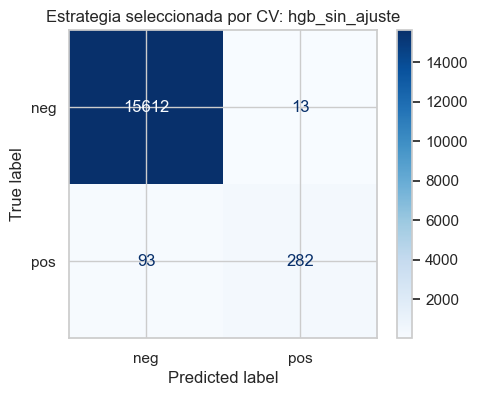

In [ ]:
y_pred = models[selected_strategy_cv].predict(X_test)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(calcular_matriz_confusion(y_test, y_pred), display_labels=["neg", "pos"]).plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title(f"Estrategia seleccionada por CV: {selected_strategy_cv}")
guardar_figura(fig, "artifacts/figures/confusion_matrix_cost_strategy.png")
plt.show()

El punto clave es que los **93 falsos negativos** tienen mucho peso en la función de coste. Por eso el resto del notebook compara si otras estrategias reducen ese tipo de error, aunque puedan generar más falsos positivos.

## Umbrales

En este notebook no se ajusta ningún umbral con test. Las estrategias se comparan con el umbral de decisión fijado por cada modelo y por el procedimiento de entrenamiento.

Esta aclaración es importante porque ajustar un umbral mirando test sería una forma de fuga de información. Test dejaría de ser una evaluación final independiente y pasaría a influir en el diseño del sistema.

Si se quisiera optimizar un umbral para reducir coste, habría que hacerlo dentro de train. Por ejemplo, se podría usar una validación interna o incluir el criterio de coste dentro del proceso de selección. Ese experimento tendría que definirse antes de mirar test.

## Lectura final de coste

La estrategia seleccionada por CV según **average precision** es **hgb_sin_ajuste**. La comparativa final en test muestra otra lectura interesante. **logistic_class_weight** obtiene el menor coste total porque reduce mucho los falsos negativos.

La diferencia aparece porque **PR-AUC** y **coste asimétrico** priorizan objetivos distintos. **PR-AUC** evalúa la capacidad del modelo para ordenar positivos en un problema desbalanceado. El coste penaliza directamente cada tipo de error, y en este proyecto castiga mucho más los falsos negativos que los falsos positivos.

Esto no es una contradicción ni un error experimental. Es una evidencia de que la elección de la métrica cambia la interpretación del resultado. Si el objetivo principal es mantener buen ranking, buen F1 y pocas falsas alarmas, **hgb_sin_ajuste** es una estrategia sólida. Si el objetivo operativo fuera minimizar coste bajo esta función concreta, **logistic_class_weight** sería una alternativa atractiva.

La decisión importante para la memoria es separar bien ambas ideas. El modelo principal no se cambia mirando test. Test solo muestra la consecuencia final de las estrategias ya fijadas. Si en un despliegue real se quisiera priorizar coste, habría que definir esa métrica desde el principio y seleccionar la estrategia dentro de train con validación cruzada. 